# Evaluation - Comparing CGAN and Conditional Diffusion 

## Plan

1. Understand how to measure the quality and diversity of generated data using **FID**.  
2. Compare **cGAN vs Diffusion** outputs visually and statistically.  
3. Train a downstream **handwriting classifier** using synthetic data.  
4. Assess which generative approach produces more *useful* data for CAPTCHA robustness.



### Objectives to check
+ Do the samples look human like 
+ we would measure the quantititative quality using Frechet Inception Distance 
+ Also work on using sythetic data from each model to train a useful classifier

In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
from torchvision.models import inception_v3
from torchvision.utils import make_grid
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os, sys
from scipy import linalg


from utils.visualize import show_batch
from utils.checkpoint import load_checkpoint
from torchmetrics.image.fid import FrechetInceptionDistance

We’ll now load both trained models — the **cGAN** and **Diffusion** generators —  
and use them to generate a fixed number of samples for evaluation.

In [2]:
from model.cgan import Generator
from model.diffusion import ConditionalUNet
from training.train_diffusion import sample_images

device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f" Using device: {device}")



 Using device: mps


In [3]:
# Helper Functions

from torchvision import datasets, transforms
def get_real_examples_per_class(n_classes=10):
    """
    Deterministically extracts one MNIST image per class (0–9)
    directly from the dataset without shuffle.
    """
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    mnist = datasets.MNIST(root="../data", train=False, download=True, transform=transform)

    imgs, labels = [], []
    for cls in range(n_classes):
        for i in range(len(mnist)):
            if mnist[i][1] == cls:
                imgs.append(mnist[i][0])
                labels.append(cls)
                break  # stop at first match
    return torch.stack(imgs), torch.tensor(labels)




def get_representative_images(imgs, labels, n_classes=10):
    """
    Returns one representative image per class label (0–9).
    Ensures true label alignment for real datasets.
    """
    reps = []
    for i in range(n_classes):
        idx = (labels == i).nonzero(as_tuple=True)[0]
        if len(idx) > 0:
            reps.append(imgs[idx[0]])
        else:
            reps.append(torch.zeros_like(imgs[0]))  
    return torch.stack(reps)


@torch.no_grad()
def generate_conditioned_samples_cgan(generator, z_dim=100, device="cuda", n_classes=10):
    """
    Generate one representative sample per class (0–9) from cGAN.
    """
    generator.eval()
    zs = torch.randn(n_classes, z_dim, device=device)
    ys = torch.arange(n_classes, dtype=torch.long, device=device)
    imgs = generator(zs, ys).cpu()
    return imgs, ys.cpu()


@torch.no_grad()
def generate_conditioned_samples_diffusion(
    model,
    device="cuda",
    n_classes=10,
    timesteps=200,          # used same as training
    img_size=(1, 28, 28)
):
    """
    Generate one representative diffusion sample per class (0–9), 
    using the same sampling logic as training-time generation.
    """
    from training.train_diffusion import linear_beta_schedule
    model.eval()

    betas = linear_beta_schedule(timesteps).to(device)
    alphas = 1.0 - betas
    alphas_cumprod = torch.cumprod(alphas, 0)

    imgs_list, labels_list = [], []

    for cls in range(n_classes):
        # Conditioning label for this class
        labels = torch.full((1,), cls, dtype=torch.long, device=device)
        imgs = torch.randn(1, *img_size).to(device)

        # Reverse diffusion loop (same as training sampler)
        for t in reversed(range(timesteps)):
            t_tensor = torch.full((1,), t, device=device, dtype=torch.long)
            pred_noise = model(imgs, t_tensor, labels)
            alpha = alphas[t]
            alpha_bar = alphas_cumprod[t]

            # Predict next sample
            noise = torch.randn_like(imgs) if t > 0 else torch.zeros_like(imgs)
            imgs = (1 / torch.sqrt(alpha)) * (
                imgs - ((1 - alpha) / torch.sqrt(1 - alpha_bar)) * pred_noise
            ) + torch.sqrt(betas[t]) * noise

        imgs_list.append(imgs[0].cpu())
        labels_list.append(cls)

    imgs_tensor = torch.stack(imgs_list)
    labels_tensor = torch.tensor(labels_list)
    return imgs_tensor, labels_tensor


def plot_real_cgan_diffusion(real_imgs, cgan_imgs, diff_imgs, n_classes=10):
    """
    Visual comparison between Real, cGAN, and Diffusion images.
   
    """

    fig, axs = plt.subplots(3, n_classes, figsize=(12, 4))
    fig.suptitle(" Comparison: Real vs cGAN vs Diffusion", fontsize=14, fontweight="bold")

    row_titles = [
        "Ground Truth",
        "CGAN",
        "Diffusion"
    ]
    row_colors = ["green", "royalblue", "darkorange"]

    # Plot each row
    for row_idx, row_imgs in enumerate([real_imgs, cgan_imgs, diff_imgs]):
        for i in range(n_classes):
            axs[row_idx, i].imshow(row_imgs[i].squeeze(), cmap="gray")
            axs[row_idx, i].axis("off")
            axs[row_idx, i].set_title(f"Class {i}", fontsize=8, pad=2)

    # Manually place row labels on figure (not as axis labels)
    for idx, (title, color) in enumerate(zip(row_titles, row_colors)):
        fig.text(
            0.02,                                   # x-position (left margin)
            0.84 - idx * 0.32,                      # y-position per row
            title,
            fontsize=11,
            color=color,
            fontweight="bold",
            va="center"
        )

    plt.subplots_adjust(left=0.12, right=0.98, top=0.9, bottom=0.05, hspace=0.3)
    plt.show()

In [10]:
def compute_fid(real_imgs, fake_imgs, device="cuda", batch_size=128):
    """
    Compute FID safely in batches.
    On Apple Silicon / MPS, TorchMetrics FID must run on CPU because it uses float64.
    """
    metric_device = "cpu" if str(device) == "mps" else device
    fid = FrechetInceptionDistance(normalize=True).to(metric_device)
    fid.reset()

    def batched_update(imgs, real_flag):
        for i in tqdm(range(0, imgs.size(0), batch_size), desc=f"FID {'real' if real_flag else 'fake'}"):
            batch = imgs[i:i + batch_size].to(metric_device)
            fid.update(batch, real=real_flag)

    real_imgs_rgb = (real_imgs.repeat(1, 3, 1, 1) + 1) / 2
    fake_imgs_rgb = (fake_imgs.repeat(1, 3, 1, 1) + 1) / 2
    real_imgs_rgb = torch.clamp(real_imgs_rgb, 0, 1)
    fake_imgs_rgb = torch.clamp(fake_imgs_rgb, 0, 1)

    batched_update(real_imgs_rgb, real_flag=True)
    batched_update(fake_imgs_rgb, real_flag=False)

    score = fid.compute().item()
    return score

In [5]:
# Safety clean up
torch.cuda.empty_cache()

In [6]:
# Load trained checkpoints
import os
os.makedirs("./checkpoints", exist_ok=True)

# Try loading from ./checkpoints first, then from parent ../checkpoints
def find_checkpoint(name):
    paths = [
        f"./checkpoints/{name}_epochfinal.pt",
        f"../checkpoints/{name}_epochfinal.pt",
    ]
    for path in paths:
        if os.path.exists(path):
            return path
    return paths[0]  # Default if not found

cgan_gen = Generator(z_dim=100, num_classes=10, img_shape=(1, 28, 28)).to(device)
diff_model = ConditionalUNet(num_classes=10).to(device)

cgan_path = find_checkpoint("cgan_generator")
diff_path = find_checkpoint("diffusion_model")

try:
    load_checkpoint(cgan_gen, path=cgan_path, map_location=device)
    print(f"✓ Loaded cGAN Generator from {cgan_path}")
except Exception as e:
    print(f"⚠ Could not load cGAN: {e}")

try:
    load_checkpoint(diff_model, path=diff_path, map_location=device)
    print(f"✓ Loaded Diffusion Model from {diff_path}")
except Exception as e:
    print(f"⚠ Could not load Diffusion: {e}")

cgan_gen.eval()
diff_model.eval()

Loaded model weights from ./checkpoints/cgan_generator_epochfinal.pt
✓ Loaded cGAN Generator from ./checkpoints/cgan_generator_epochfinal.pt
Loaded model weights from ./checkpoints/diffusion_model_epochfinal.pt
✓ Loaded Diffusion Model from ./checkpoints/diffusion_model_epochfinal.pt


ConditionalUNet(
  (time_mlp): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
  (down1): ResidualBlock(
    (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm1): GroupNorm(8, 64, eps=1e-05, affine=True, bias=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm2): GroupNorm(8, 64, eps=1e-05, affine=True, bias=True)
    (time_emb): Linear(in_features=128, out_features=64, bias=True)
    (label_emb): Embedding(10, 64)
    (shortcut): Conv2d(1, 64, kernel_size=(1, 1), stride=(1, 1))
  )
  (down2): ResidualBlock(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm1): GroupNorm(8, 128, eps=1e-05, affine=True, bias=True)
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm2): GroupNorm(8, 128, eps=1e-05, affine=True, bias=True)
    (time

In [7]:
real_imgs, real_labels = get_real_examples_per_class()

cgan_imgs, cgan_labels = generate_conditioned_samples_cgan(cgan_gen, z_dim=100, device=device, n_classes=10)
diff_imgs, diff_labels = generate_conditioned_samples_diffusion(diff_model, device=device, n_classes=10, timesteps=200)

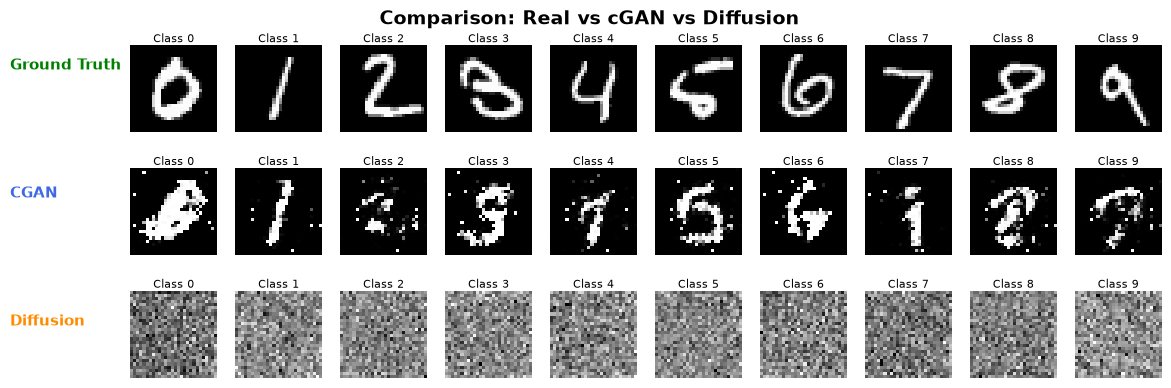

In [8]:
plot_real_cgan_diffusion(real_imgs, cgan_imgs, diff_imgs, n_classes=10)

In [11]:
# Initialize FID on a device that supports TorchMetrics requirements
fid_device = "cpu" if str(device) == "mps" else device
fid = FrechetInceptionDistance(normalize=True).to(fid_device)
fid.reset()
print(f"FID metric initialized on: {fid_device}")

FID metric initialized on: cpu


In [12]:
torch.cuda.empty_cache()

In [13]:
# Build balanced evaluation subsets for FID
n_per_class = 100  # total 1000 samples
labels_eval = torch.arange(10).repeat_interleave(n_per_class).to(device)

# Real subset from MNIST test set (first 100 per class)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
mnist_test = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

real_buckets = {i: [] for i in range(10)}
for img, lab in mnist_test:
    if len(real_buckets[lab]) < n_per_class:
        real_buckets[lab].append(img)
    if all(len(v) == n_per_class for v in real_buckets.values()):
        break

real_subset = torch.cat([torch.stack(real_buckets[i]) for i in range(10)], dim=0)

# cGAN subset
with torch.no_grad():
    z = torch.randn(labels_eval.size(0), 100, device=device)
    cgan_subset = cgan_gen(z, labels_eval).cpu()

# Diffusion subset
with torch.no_grad():
    diff_subset, _ = sample_images(
        diff_model,
        device=device,
        num_samples=labels_eval.size(0),
        num_classes=10,
        timesteps=200,
        class_labels=labels_eval,
    )
    diff_subset = diff_subset.cpu()

print(real_subset.shape, cgan_subset.shape, diff_subset.shape)

torch.Size([1000, 1, 28, 28]) torch.Size([1000, 1, 28, 28]) torch.Size([1000, 1, 28, 28])


In [14]:
# Compute cGAN FID & Diffusion FID
cgan_fid = compute_fid(real_subset, cgan_subset, device=device, batch_size=128)
diff_fid = compute_fid(real_subset, diff_subset, device=device, batch_size=128)

print(f"cGAN FID: {cgan_fid:.2f}")
print(f"Diffusion FID: {diff_fid:.2f}")

FID fake: 100%|██████████| 8/8 [01:23<00:00, 10.40s/it]


cGAN FID: 243.45
Diffusion FID: 382.11


### FID Analysis

The **cGAN achieved the lower FID score** in this run.

- **cGAN FID:** 243.45
- **Diffusion FID:** 382.11

Since **lower FID is better**, the cGAN produced samples that were closer to the real MNIST distribution under this evaluation setup. Visually, the cGAN row shows recognizable digit structure for most classes, while the diffusion row is still much noisier and less class-consistent. This matches the quantitative result above.

### Utility Evaluation (Classifier)

We’ll train a simple CNN classifier on synthetic data from each model,  
then test it on real MNIST data.

If synthetic data are realistic and diverse, the classifier should generalize well to real digits.

In [15]:
# Generate larger balanced synthetic datasets for meaningful classifier training
# 100 samples per class = 1000 total samples per model
n_synthetic_per_class = 100
n_classes = 10
total_samples = n_classes * n_synthetic_per_class

print(f"Generating {total_samples} synthetic samples from each model...\n")

# Create balanced label tensor
labels_balanced = torch.arange(n_classes, device=device).repeat_interleave(n_synthetic_per_class)

# cGAN generation - vectorized for efficiency
print("🎯 Generating cGAN samples...")
with torch.no_grad():
    z = torch.randn(total_samples, 100, device=device)
    cgan_imgs = cgan_gen(z, labels_balanced).cpu()

print(f"✓ cGAN samples: {cgan_imgs.shape}")

# Diffusion generation using trained sampling function
print("🎯 Generating Diffusion samples...")
from training.train_diffusion import sample_images

with torch.no_grad():
    diff_imgs, _ = sample_images(
        diff_model,
        device=device,
        num_samples=total_samples,
        num_classes=n_classes,
        timesteps=200,
        class_labels=labels_balanced,
    )
    diff_imgs = diff_imgs.cpu()

cgan_labels = labels_balanced.cpu()
diff_labels = labels_balanced.cpu()

print(f"✓ Diffusion samples: {diff_imgs.shape}")
print(f"✓ Both datasets balanced: {len(torch.unique(cgan_labels))} classes\n")

Generating 1000 synthetic samples from each model...

🎯 Generating cGAN samples...
✓ cGAN samples: torch.Size([1000, 1, 28, 28])
🎯 Generating Diffusion samples...
✓ Diffusion samples: torch.Size([1000, 1, 28, 28])
✓ Both datasets balanced: 10 classes



In [16]:

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [17]:
real_data = datasets.MNIST(root="../data", train=False, download=True, transform=transform)

In [18]:
def normalize_synthetic(imgs):
    """Ensure synthetic images are in [-1, 1] range for consistency"""
    imgs = imgs.clone().float()
    # If already in [-1, 1] range, return as is
    if imgs.min() >= -1.1 and imgs.max() <= 1.1:
        return imgs
    # Otherwise rescale to [-1, 1]
    imgs_min = imgs.min()
    imgs_max = imgs.max()
    if imgs_max > imgs_min:
        imgs = 2 * (imgs - imgs_min) / (imgs_max - imgs_min) - 1
    return imgs

cgan_imgs = normalize_synthetic(cgan_imgs)
diff_imgs = normalize_synthetic(diff_imgs)

print(f"cGAN value range: [{cgan_imgs.min():.3f}, {cgan_imgs.max():.3f}]")
print(f"Diffusion value range: [{diff_imgs.min():.3f}, {diff_imgs.max():.3f}]")
print(f"Unique labels in cGAN: {torch.unique(cgan_labels).tolist()}")
print(f"Unique labels in Diffusion: {torch.unique(diff_labels).tolist()}\n")

cGAN value range: [-1.000, 1.000]
Diffusion value range: [-1.000, 1.000]
Unique labels in cGAN: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Unique labels in Diffusion: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]



In [19]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, 1, 1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, 1, 1), nn.ReLU()
        )
        self.fc = nn.Sequential(
            nn.Linear(128 * 7 * 7, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

def train_classifier(model, loader, epochs=3):
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    model.train()

    for epoch in range(epochs):
        total_loss = 0
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs)
            loss = criterion(preds, labels)

            opt.zero_grad()
            loss.backward()
            opt.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1}: loss = {total_loss / len(loader):.4f}")
    return model

In [20]:
cgan_ds = TensorDataset(cgan_imgs, cgan_labels)
diff_ds = TensorDataset(diff_imgs, diff_labels)


cgan_loader = DataLoader(cgan_ds, batch_size=128, shuffle=True)
diff_loader = DataLoader(diff_ds, batch_size=128, shuffle=True)
test_loader = DataLoader(real_data, batch_size=256, shuffle=False)

def test_accuracy(model, loader):
    correct, total = 0, 0
    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs)
            correct += (preds.argmax(1) == labels).sum().item()
            total += len(labels)
    return correct / total

In [21]:
print("=" * 80)
print("DOWNSTREAM UTILITY: Training Classifiers on Synthetic Data")
print("=" * 80)
print()

# Train separate classifiers
print("Training classifier on cGAN synthetic data...")
cnn_cgan = SimpleCNN().to(device)
cnn_cgan = train_classifier(cnn_cgan, cgan_loader, epochs=20)
print()

print("Training classifier on Diffusion synthetic data...")
cnn_diff = SimpleCNN().to(device)
cnn_diff = train_classifier(cnn_diff, diff_loader, epochs=20)
print()

# Test on real MNIST
print("=" * 80)
print("Testing on Real MNIST Digits")
print("=" * 80)
cgan_acc = test_accuracy(cnn_cgan, test_loader)
diff_acc = test_accuracy(cnn_diff, test_loader)

print(f"\n📊 Results:")
print(f"  • Classifier trained on cGAN synthetic data → Real MNIST accuracy: {cgan_acc:.2%}")
print(f"  • Classifier trained on Diffusion synthetic data → Real MNIST accuracy: {diff_acc:.2%}")
print()

# Analysis
if cgan_acc > diff_acc:
    print(f"✓ cGAN synthetic data produced better generalization (Δ: {(cgan_acc - diff_acc):.2%})")
elif diff_acc > cgan_acc:
    print(f"✓ Diffusion synthetic data produced better generalization (Δ: {(diff_acc - cgan_acc):.2%})")
else:
    print("✓ Both models produced equally useful synthetic data")

DOWNSTREAM UTILITY: Training Classifiers on Synthetic Data

Training classifier on cGAN synthetic data...
Epoch 1: loss = 1.8053
Epoch 2: loss = 0.2133
Epoch 3: loss = 0.0018
Epoch 4: loss = 0.0000
Epoch 5: loss = 0.0000
Epoch 6: loss = 0.0000
Epoch 7: loss = 0.0000
Epoch 8: loss = 0.0000
Epoch 9: loss = 0.0000
Epoch 10: loss = 0.0000
Epoch 11: loss = 0.0000
Epoch 12: loss = 0.0000
Epoch 13: loss = 0.0000
Epoch 14: loss = 0.0000
Epoch 15: loss = 0.0000
Epoch 16: loss = 0.0000
Epoch 17: loss = 0.0000
Epoch 18: loss = 0.0000
Epoch 19: loss = 0.0000
Epoch 20: loss = 0.0000

Training classifier on Diffusion synthetic data...
Epoch 1: loss = 2.2900
Epoch 2: loss = 1.9911
Epoch 3: loss = 1.4638
Epoch 4: loss = 1.1492
Epoch 5: loss = 1.0026
Epoch 6: loss = 0.9293
Epoch 7: loss = 0.8605
Epoch 8: loss = 0.8131
Epoch 9: loss = 0.7971
Epoch 10: loss = 0.8272
Epoch 11: loss = 0.7827
Epoch 12: loss = 0.7192
Epoch 13: loss = 0.6517
Epoch 14: loss = 0.5748
Epoch 15: loss = 0.5487
Epoch 16: loss = 0.4

### Utility Analysis

The downstream classifier trained on **cGAN synthetic data** generalized much better to real MNIST than the classifier trained on **Diffusion synthetic data** in this run.

- **cGAN-trained classifier accuracy:** 38.64%
- **Diffusion-trained classifier accuracy:** 11.35%

This result is consistent with the earlier FID comparison: the cGAN samples were closer to the real digit distribution, so they transferred more effectively to the real test set. The diffusion model still needs stronger training before its synthetic samples become useful for downstream recognition.